# 텍스트 빈도수 시각화 : 단어 빈도 그래프, 워드클라우드
1. 데이터 수집(로딩)
1. 텍스트 전처리
1. 빈도수 계산
1. 단어 빈도 그래프 시각화
1. 워드클라우드 시각화

## 1. 데이터 수집(로딩)

In [34]:
# 실습 문서 : 대한민국 헌법
from konlpy.corpus import kolaw
input_filename = 'constitution.txt'
const_doc = kolaw.open(input_filename).read()

#가져온 데이터 확인 (타입, 길이, 일부 데이터)
type(const_doc), len(const_doc), const_doc[:50]

(str, 18884, '대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임')

## 2. 텍스트 전처리
* 한글 : 품사 태깅 -> 필요 품사 단어만 사용 -> 불용어 삭제

In [35]:
from konlpy.tag import Okt
okt = Okt()
# 명사만 추출
no = okt.nouns(const_doc)
# 토큰 수
len(no)
# 토큰 일부 확인
no[:10]

['대한민국', '헌법', '유구', '역사', '전통', '우리', '국민', '운동', '건립', '대한민국']

In [45]:
# 명사(일반 명사, 고유 명사), 동사, 형용사 단어 추출
mytags = set(['Noun', 'Verb', 'Adjective'])
# 불용어 삭제 : 의미없는데 고빈도로 나오는 단어 추가
my_stopwords = set('하는 한다 의하여 하여 있다 하며 하여야'.split())
res = [word for word, tag in okt.pos(const_doc) if tag in mytags and word not in my_stopwords and len(word) > 1]

# 토큰 수
len(res)
# 토큰 일부 확인
res[:10]

['대한민국', '헌법', '유구', '역사', '전통', '빛나는', '우리', '국민', '운동', '건립']

## 3.  빈도수 계산

In [46]:
# Counter 객체 생성
from collections import Counter
const_counter = Counter(res)
# 단어 수
len(const_counter)
# Counter 객체 내 (단어, 빈도수) 확인
print(list(const_counter.items())[:10])

[('대한민국', 11), ('헌법', 53), ('유구', 1), ('역사', 1), ('전통', 1), ('빛나는', 1), ('우리', 3), ('국민', 61), ('운동', 2), ('건립', 1)]


In [47]:
# 빈도수 상위 단어의 (단어, 빈도수) 튜플 리스트 추출
const_counter.most_common(50)

[('법률', 127),
 ('대통령', 83),
 ('국가', 73),
 ('국회', 68),
 ('국민', 61),
 ('헌법', 53),
 ('모든', 37),
 ('아니', 30),
 ('기타', 26),
 ('가진다', 25),
 ('사항', 23),
 ('권리', 21),
 ('된다', 21),
 ('필요한', 21),
 ('없다', 21),
 ('의원', 21),
 ('자유', 20),
 ('정부', 20),
 ('선거', 20),
 ('임명', 20),
 ('되지', 19),
 ('직무', 19),
 ('국무총리', 19),
 ('경제', 18),
 ('의무', 18),
 ('조직', 18),
 ('국회의원', 18),
 ('임기', 18),
 ('의결', 17),
 ('공무원', 17),
 ('경우', 17),
 ('이상', 17),
 ('국무위원', 17),
 ('대법원', 17),
 ('하기', 16),
 ('범위', 16),
 ('이를', 15),
 ('받지', 15),
 ('법관', 15),
 ('보호', 14),
 ('정책', 14),
 ('정당', 14),
 ('헌법재판소', 14),
 ('재적', 14),
 ('회의', 14),
 ('항의', 14),
 ('관리', 14),
 ('진다', 13),
 ('노력', 13),
 ('보장', 13)]

## 4. 단어 빈도 그래프 시각화
1. 데이터 준비
2. 그래프 정보 추가
3. 막대 그래프 생성
4. 그래프 출력 (화면, 파일)

In [ ]:
# 데이터 준비 : 빈도수 상위 20개의 단어만 추출
# x 데이터 : word, y 데이터 : count
co = const_counter.most_common(20)
x = [x for x,y in co]
y = [y for x,y in co]

['법률', '대통령', '국가', '국회', '국민', '헌법', '모든', '아니', '기타', '가진다', '사항', '권리', '된다', '필요한', '없다', '의원', '자유', '정부', '선거', '임명'] [127, 83, 73, 68, 61, 53, 37, 30, 26, 25, 23, 21, 21, 21, 21, 21, 20, 20, 20, 20]


In [49]:
# matplotlib 한글 폰트 설정
from matplotlib import font_manager, rc
font_path = "c:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

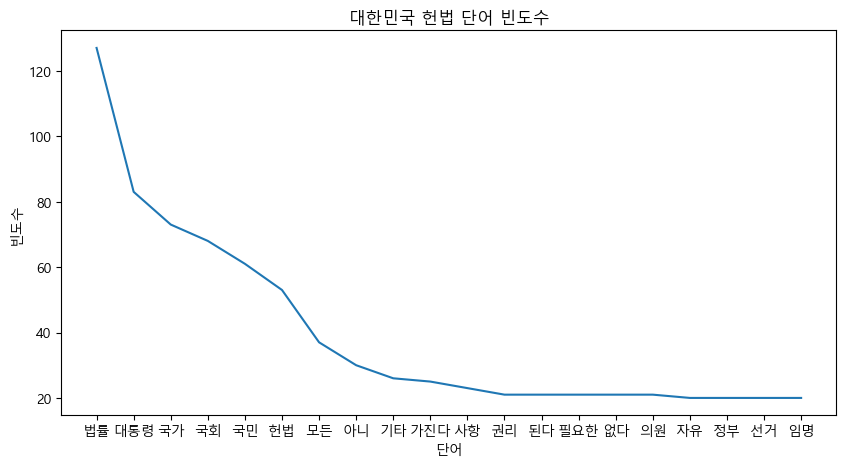

In [66]:
import matplotlib.pyplot as plt

# 선그래프
plt.figure(figsize=(10,5))
plt.plot(x,y)
# 그래프 정보 추가 
plt.title('대한민국 헌법 단어 빈도수')
plt.xlabel('단어')
plt.ylabel('빈도수')
# 그래프 저장
outputfile = input_filename.replace('.txt', '_graph.png')
plt.savefig(f'result/{outputfile}')
# 화면에 출력
plt.show()

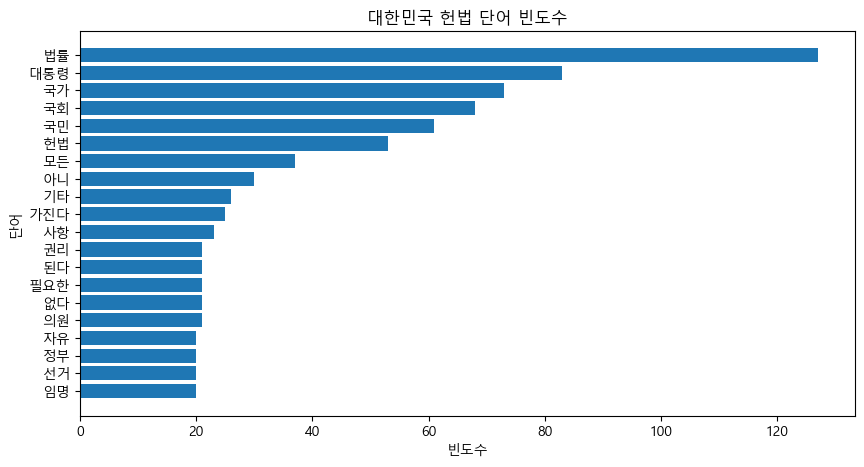

In [67]:
# 수평 막대그래프
plt.figure(figsize=(10,5))
plt.barh(x[::-1],y[::-1])
# 그래프 정보 추가 
plt.title('대한민국 헌법 단어 빈도수')
plt.xlabel('빈도수')
plt.ylabel('단어')
# 그래프 저장
plt.savefig(f'result/{outputfile}')
# 화면에 출력
plt.show()

### 03-5. 워드 클라우드 시각화

* conda 환경에서 wordcloud 설치 (conda install wordcloud)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 한글 폰트 path 지정
font_path = "c:/Windows/fonts/malgun.ttf"

# WordCloud 객체 생성
wc = WordCloud(font_path=font_path, 
               background_color='white', 
               colormap='spring', # summer, Set2, Pastel1
               max_words=100,
               width=800,
               height=600)

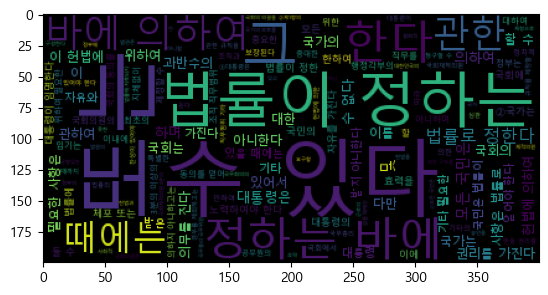

In [76]:
# 전체 텍스트로 워드클라우드 시각화
wc = wc.generate(const_doc)
plt.imshow(wc)

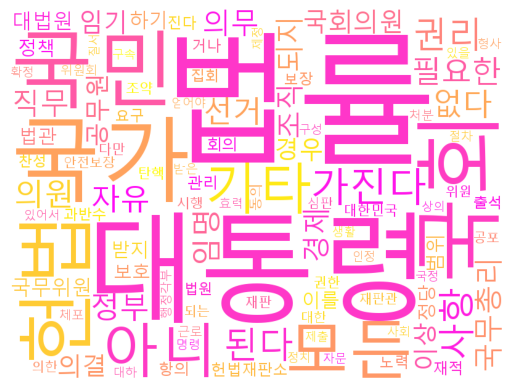

In [91]:
# 빈도 데이터로 워드클라우드 시각화
wc = wc.generate_from_frequencies(const_counter)
plt.imshow(wc)
plt.axis('off')
plt.show()

In [93]:
# wordcloud 이미지 저장
wc.to_file(f"result/{input_filename.replace('.txt','_wordcloud.jpg')}")